# **Modelling: XGBoost for PJME Electricity Consumption Data**

### **Learning Resources**
[Getting started with XGBoost](https://www.youtube.com/watch?v=vV12dGe_Fho) by Rob Mulla  
[Advanced Time-series Techniques](https://www.youtube.com/watch?v=z3ZnOW-S550&t=1s) by Rob Mulla  
[TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) from sklearn docs

### **Learning Points**
* If plot shows weird lines, it is likely because the df index is not sorted. `df = df.sort_index()`
* Calculate and sort descending `error` as a way to quickly see where your model performs poorly or to identify anomalous data points `error = actual - pred`
* Time-series split (Cross-validation) tests whether the model generalises forward in time, which is the actual real-world task. Normal cross-validation is invalid, the model would train on future data to predict the past, breaking temporal dependencies (past values influence today's value)

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error

import xgboost as xgb

# global plot style
plt.style.use('fivethirtyeight')
sns.set_theme(
  style='darkgrid',
  palette='muted',
  rc={
    'figure.figsize': (15, 5),
    'axes.titlesize': 20,
    'axes.titleweight': 'bold',
  }
)

---

In [2]:
df = pd.read_csv("../data/processed/PJME_hourly_processed.csv")
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df = df.sort_index()

## Model Training

In [3]:
tscv = TimeSeriesSplit(
  test_size=24*7*12, 
  gap=24
) # 12 weeks per fold

TARGET = 'PJME_MW'

### v1: Baseline Calendar Features

Fold 0: Train=109035 rows, Test=2016 rows
Fold 1: Train=111051 rows, Test=2016 rows
Fold 2: Train=113067 rows, Test=2016 rows
Fold 3: Train=115083 rows, Test=2016 rows
Fold 4: Train=117099 rows, Test=2016 rows


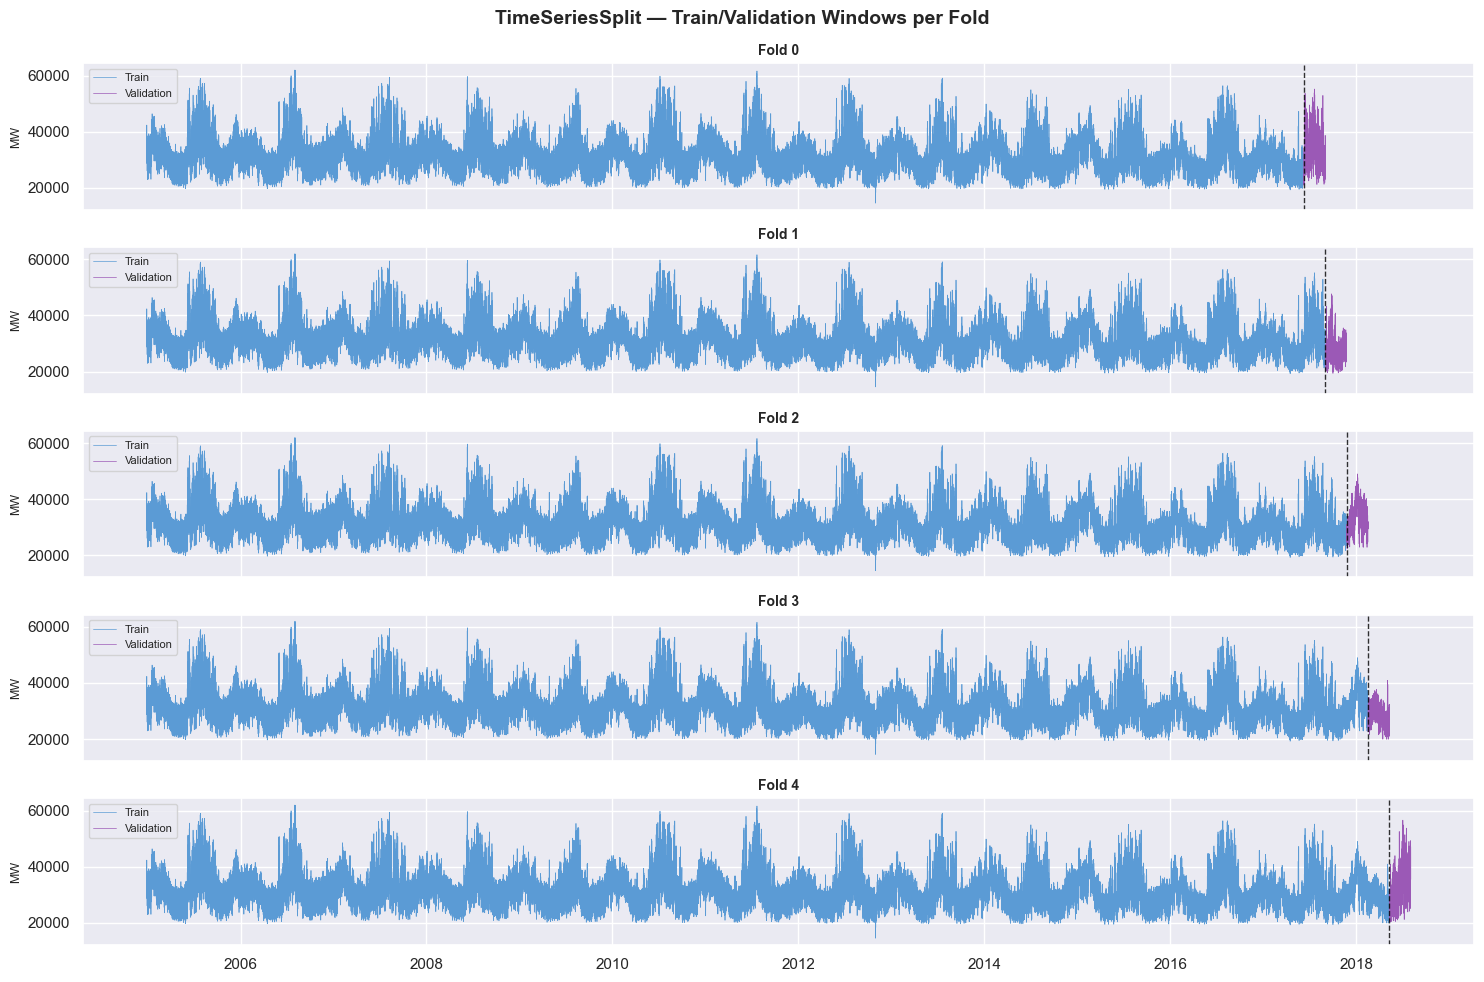

[0]	validation_0-rmse:6487.56412	validation_1-rmse:7745.73339
[100]	validation_0-rmse:4690.22240	validation_1-rmse:5246.99973
[200]	validation_0-rmse:4034.17324	validation_1-rmse:4579.23003
[300]	validation_0-rmse:3656.47686	validation_1-rmse:4498.18851
[400]	validation_0-rmse:3445.66021	validation_1-rmse:4473.85035
[500]	validation_0-rmse:3323.79837	validation_1-rmse:4464.67467
[505]	validation_0-rmse:3319.30998	validation_1-rmse:4462.36053
Fold 0 RMSE: 4459.8MW
[0]	validation_0-rmse:6512.36955	validation_1-rmse:6123.18218
[100]	validation_0-rmse:4697.52981	validation_1-rmse:5018.30159
[200]	validation_0-rmse:4051.80719	validation_1-rmse:4608.03801
[300]	validation_0-rmse:3684.23668	validation_1-rmse:4343.75928
[400]	validation_0-rmse:3472.58123	validation_1-rmse:4181.97016
[500]	validation_0-rmse:3352.25550	validation_1-rmse:4119.34881
[600]	validation_0-rmse:3278.06000	validation_1-rmse:4089.19695
[660]	validation_0-rmse:3245.03347	validation_1-rmse:4099.89440
Fold 1 RMSE: 4086.5MW


In [4]:
FEATURES = [
  'hour', 'dayofweek', 'month', 'quarter', 'year', 'dayofyear', 'dayofmonth', 'weekofyear'
]

# collect data for the 5 regressors across 5 folds for analysis later
fold_scores = []
predictions_raw = pd.DataFrame()
feature_importances = pd.DataFrame(index=FEATURES)

fig, axes = plt.subplots(5, 1, figsize=(15, 10), sharex=True)
fig.suptitle('TimeSeriesSplit — Train/Validation Windows per Fold', fontsize=14, fontweight='bold')

for fold, (train_idx, test_idx) in enumerate(tscv.split(df[TARGET])):
  print(f"Fold {fold}: Train={len(train_idx)} rows, Test={len(test_idx)} rows")

  # Slice dataset
  X_train, y_train = df[FEATURES].iloc[train_idx], df[TARGET].iloc[train_idx]
  X_test,  y_test  = df[FEATURES].iloc[test_idx],  df[TARGET].iloc[test_idx]

  # Plot train/validation split per fold
  ax = axes[fold]
  ax.plot(y_train.index, y_train.values, color='#5B9BD5', linewidth=0.5, label='Train')
  ax.plot(y_test.index,  y_test.values,  color='#9B59B6', linewidth=0.5, label='Validation')
  ax.axvline(y_test.index.min(), color="black", linewidth=1, alpha=0.8, ls="--")
  ax.set_ylabel('MW', fontsize=9)
  ax.set_title(f'Fold {fold}', fontsize=10)
  ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

for fold, (train_idx, test_idx) in enumerate(tscv.split(df[TARGET])):

  # Slice dataset
  X_train, y_train = df[FEATURES].iloc[train_idx], df[TARGET].iloc[train_idx]
  X_test,  y_test  = df[FEATURES].iloc[test_idx],  df[TARGET].iloc[test_idx]

  # Train XGB
  reg = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    early_stopping_rounds=50, # prevent overfitting by stopping model if validation metric (RMSE) increases above previous rounds
    eval_metric='rmse',
    seed=42
  )
  reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
  )

  # Predict
  preds = reg.predict(X_test)
  score = np.sqrt(np.mean((preds - y_test)**2)) # RMSE in MW
  fold_scores.append(score)
  print(f"Fold {fold} RMSE: {score:.1f}MW")

  # Save data (feat importances, predictions)
  fold_preds = pd.DataFrame({
    'actual':   y_test.values,
    'predicted': preds,
    'fold':      fold
  }, index=y_test.index)
  predictions_raw = pd.concat([predictions_raw, fold_preds])
  feature_importances[f'fold_{fold}'] = reg.feature_importances_

print(f"\nMean RMSE: {np.mean(fold_scores):.1f} ± {np.std(fold_scores):.1f} MW")

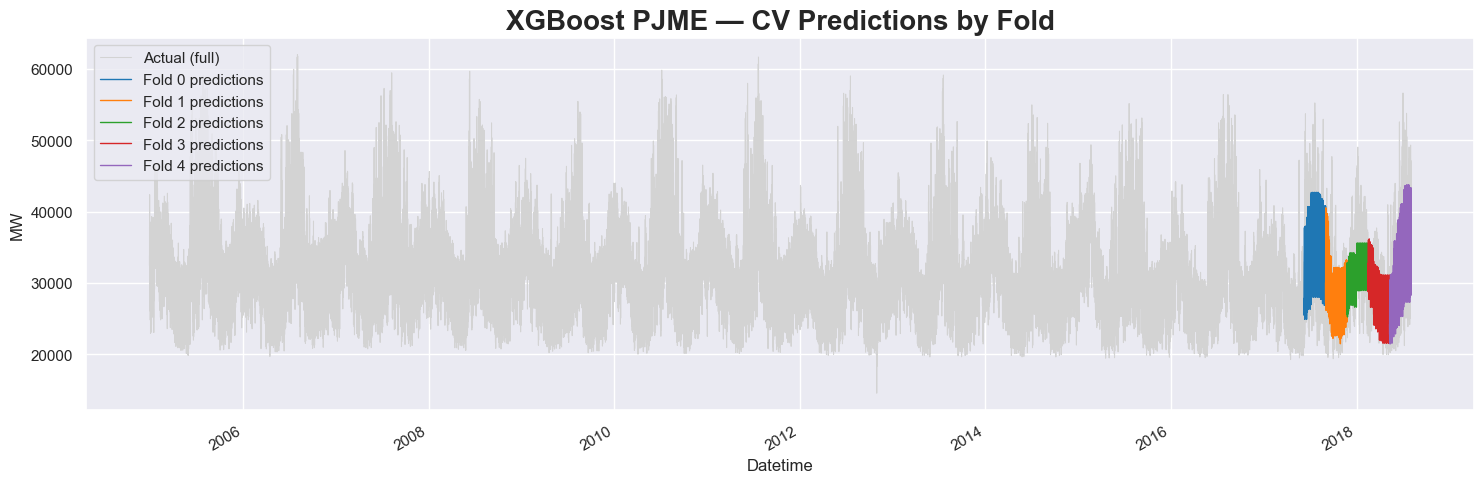

In [5]:
fig, ax = plt.subplots(figsize=(15, 5))

# Full actual series in the background
df[TARGET].plot(ax=ax, color='lightgray', label='Actual (full)', linewidth=0.75)

# Overlay each fold's predictions in a distinct color
colors = plt.cm.tab10.colors
for fold in predictions_raw['fold'].unique():
  mask = predictions_raw['fold'] == fold
  predictions_raw.loc[mask, 'predicted'].plot(
    ax=ax, color=colors[fold], label=f'Fold {fold} predictions', linewidth=1
  )

ax.set_title('XGBoost PJME — CV Predictions by Fold')
ax.set_xlabel('Datetime')
ax.set_ylabel('MW')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

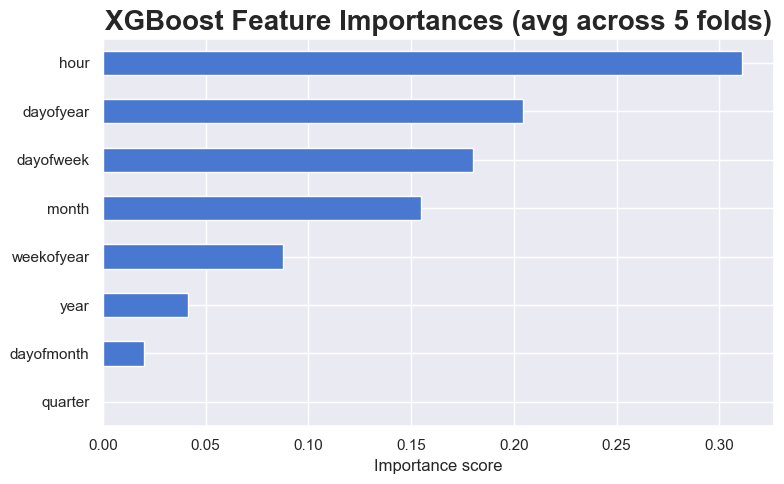

In [6]:
# avg across folds and sort
feature_importances['mean'] = feature_importances.mean(axis=1)
feature_importances = feature_importances.sort_values('mean', ascending=True)

feature_importances['mean'].plot(
  kind='barh',
  figsize=(8, 5),
  title='XGBoost Feature Importances (avg across 5 folds)'
)
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

Features like month and dayofyear are highly correlated. Removing month may cause the importance of dayofyear to spike. The raw feature importances are not always the most reliable metric to evaluate each individual feature, moreso how they all work together.

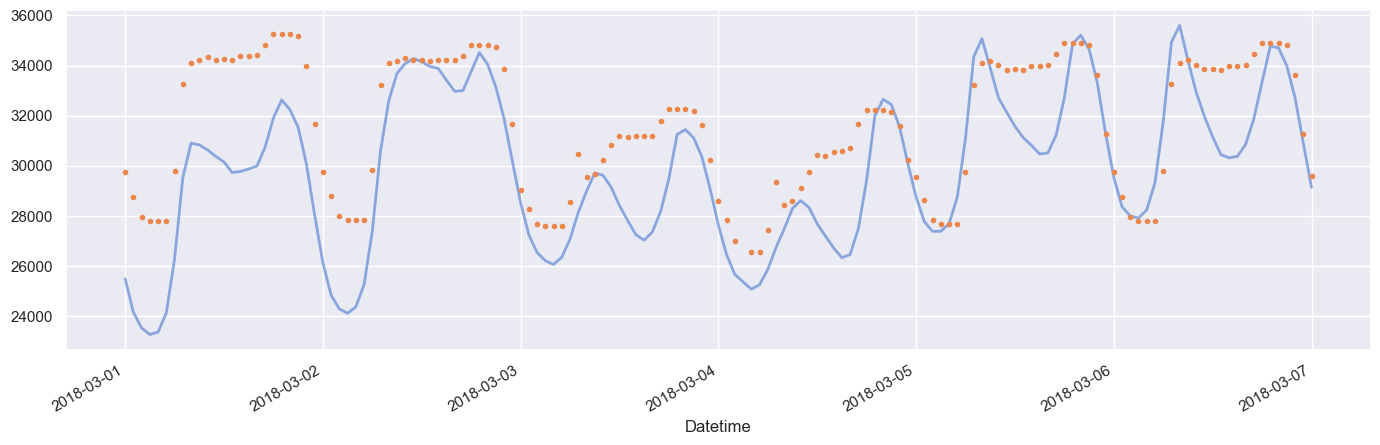

In [7]:
YEAR = 2018
MONTH = 3

mask = (predictions_raw.index >= f'{YEAR}-{MONTH}-01') & (predictions_raw.index <= f'{YEAR}-{MONTH}-07')
predictions_raw.loc[mask, "actual"].plot(linewidth=2, alpha=0.6)
predictions_raw.loc[mask, "predicted"].plot(
  style=".",
  linewidth=3
)
plt.show()

### v2-v6: Experiment New Features

In [8]:
def run_experiment(df, label, features, params, tscv, target=TARGET):
  fold_scores = {"rmse": [], "mape": []}
  predictions = pd.DataFrame()
  feature_importances = pd.DataFrame(index=features)

  for fold, (train_idx, test_idx) in enumerate(tscv.split(df[target])):
    X_train, y_train = df[features].iloc[train_idx], df[target].iloc[train_idx]
    X_test,  y_test  = df[features].iloc[test_idx],  df[target].iloc[test_idx]

    reg = xgb.XGBRegressor(**params)
    reg.fit(
      X_train, y_train,
      eval_set=[(X_train, y_train), (X_test, y_test)],
      verbose=False
    )

    num_trees = reg.best_iteration
    preds = reg.predict(X_test)
    rmse = np.sqrt(np.mean((preds - y_test) ** 2))
    mape = mean_absolute_percentage_error(y_test, preds) * 100
    fold_scores["rmse"].append(rmse)
    fold_scores["mape"].append(mape)

    fold_preds = pd.DataFrame({
      'actual':    y_test.values,
      'predicted': preds,
      'fold':      fold
    }, index=y_test.index)
    predictions = pd.concat([predictions, fold_preds])
    feature_importances[f'fold_{fold}'] = reg.feature_importances_

  feature_importances['mean'] = feature_importances.mean(axis=1)
  mean_rmse = np.mean(fold_scores["rmse"])
  mean_mape = np.mean(fold_scores["mape"])
  print(f"{label} ({num_trees} trees)\n\tMean RMSE: {mean_rmse:.1f} ± {np.std(fold_scores["rmse"]):.1f} MW\n\tMean MAPE: {mean_mape:.1f}%")

  return {
    'label':               label,
    'predictions':         predictions,
    'feature_importances': feature_importances['mean'].sort_values(ascending=True),
    'fold_scores':         fold_scores,
    'mean_rmse':           mean_rmse,
    'mean_mape':           mean_mape,
  }


def plot_comparison(results, year=2018, month=2):
  START = f'{year}-{month:02d}-01'
  END   = f'{year}-{month:02d}-08'
  n     = len(results)

  fig, axes = plt.subplots(n, 2, figsize=(18, 5 * n))
  fig.suptitle('Model Comparison', fontsize=28, fontweight='bold', y=1.01)

  for i, r in enumerate(results):
    preds = r['predictions']
    fi    = r['feature_importances']
    mask  = (preds.index >= START) & (preds.index <= END)
    week  = preds.loc[mask]

    rmse = np.sqrt(np.mean((week['predicted'] - week['actual']) ** 2))
    mape = mean_absolute_percentage_error(week['actual'], week['predicted']) * 100

    # Feature importances
    ax_fi = axes[i, 0]
    fi.plot(kind='barh', ax=ax_fi)
    ax_fi.set_title(r['label'], fontweight='bold')
    ax_fi.set_xlabel('Importance score')

    # Actual vs predicted
    ax_pred = axes[i, 1]
    ax_pred.plot(week.index, week['actual'],    label='Actual',    linewidth=2)
    ax_pred.plot(week.index, week['predicted'], label='Predicted', linewidth=1.5, linestyle='dotted')
    ax_pred.set_title(f'Feb {month:02d} – Feb 08\nRMSE={rmse:.1f} MW  MAPE={mape:.2f}%', fontsize=11)
    ax_pred.set_xlabel('Datetime')
    ax_pred.set_ylabel('MW')
    ax_pred.legend()
    ax_pred.tick_params(axis='x', rotation=30)

  plt.tight_layout()
  plt.show()

V1 — Baseline (413 trees)
	Mean RMSE: 3821.9 ± 699.5 MW
	Mean MAPE: 8.9%
V2 — V1 + Annual Lags (399 trees)
	Mean RMSE: 3862.1 ± 802.8 MW
	Mean MAPE: 9.0%
V3 — V2 + Rolling Demand (1997 trees)
	Mean RMSE: 1885.2 ± 268.4 MW
	Mean MAPE: 4.3%
V4 — V3 + Holiday (1999 trees)
	Mean RMSE: 1881.6 ± 266.4 MW
	Mean MAPE: 4.3%
V5 — V4 + Raw Temperature (1996 trees)
	Mean RMSE: 1169.0 ± 135.4 MW
	Mean MAPE: 2.8%
V6 — V5 + Heating/Cooling Degrees (1997 trees)
	Mean RMSE: 1170.7 ± 135.7 MW
	Mean MAPE: 2.8%
V7 — V6 + Rolling Temperature (1999 trees)
	Mean RMSE: 1156.4 ± 139.7 MW
	Mean MAPE: 2.7%


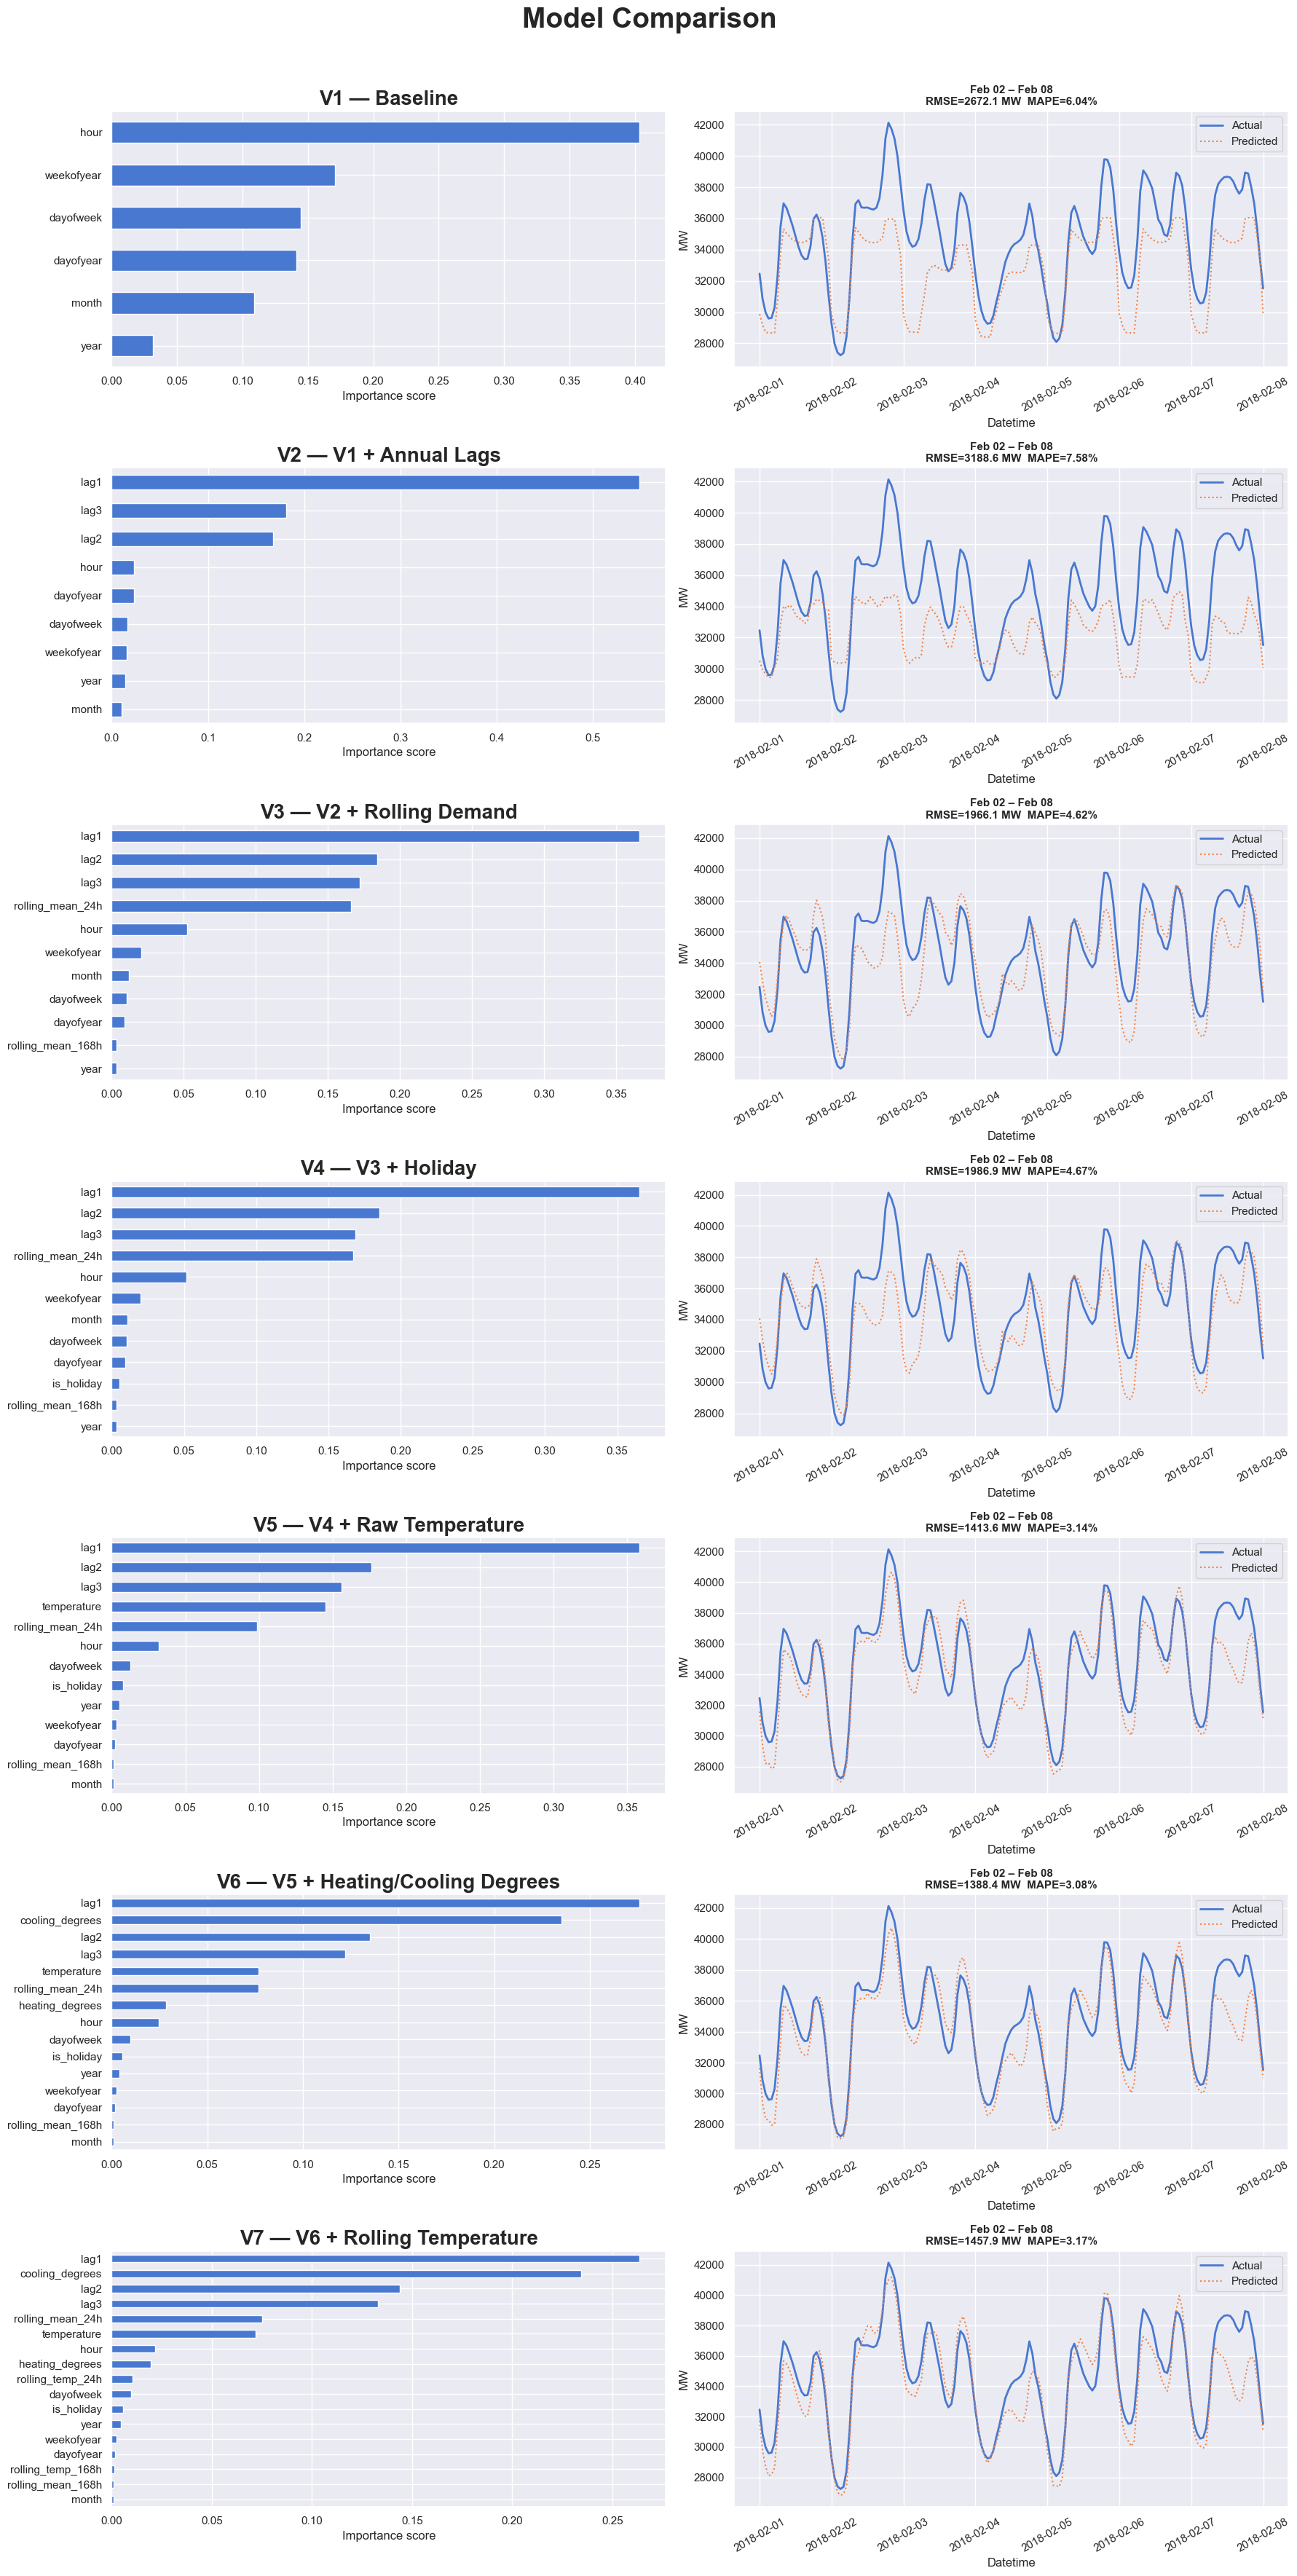

In [14]:
# Experiment configs
BASE_PARAMS = dict(
  learning_rate=0.01,
  early_stopping_rounds=50,
  eval_metric='rmse',
  seed=42
)

experiments = [
    {
        'label':    'V1 — Baseline',
        'features': ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear'],
        'params':   {**BASE_PARAMS, 'n_estimators': 2000, 'max_depth': 5},
    },
    {
        'label':    'V2 — V1 + Annual Lags',
        'features': ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
                     'lag1', 'lag2', 'lag3'],
        'params':   {**BASE_PARAMS, 'n_estimators': 2000, 'max_depth': 5},
    },
    {
        'label':    'V3 — V2 + Rolling Demand',
        'features': ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
                     'lag1', 'lag2', 'lag3',
                     'rolling_mean_24h', 'rolling_mean_168h'],
        'params':   {**BASE_PARAMS, 'n_estimators': 2000, 'max_depth': 5},
    },
    {
        'label':    'V4 — V3 + Holiday',
        'features': ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
                     'lag1', 'lag2', 'lag3',
                     'rolling_mean_24h', 'rolling_mean_168h',
                     'is_holiday'],
        'params':   {**BASE_PARAMS, 'n_estimators': 2000, 'max_depth': 5},
    },
    {
        'label':    'V5 — V4 + Raw Temperature',
        'features': ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
                     'lag1', 'lag2', 'lag3',
                     'rolling_mean_24h', 'rolling_mean_168h',
                     'is_holiday',
                     'temperature'],
        'params':   {**BASE_PARAMS, 'n_estimators': 2000, 'max_depth': 5},
    },
    {
        'label':    'V6 — V5 + Heating/Cooling Degrees',
        'features': ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
                     'lag1', 'lag2', 'lag3',
                     'rolling_mean_24h', 'rolling_mean_168h',
                     'is_holiday',
                     'temperature', 'heating_degrees', 'cooling_degrees'],
        'params':   {**BASE_PARAMS, 'n_estimators': 2000, 'max_depth': 5},
    },
    {
        'label':    'V7 — V6 + Rolling Temperature',
        'features': ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
                     'lag1', 'lag2', 'lag3',
                     'rolling_mean_24h', 'rolling_mean_168h',
                     'is_holiday',
                     'temperature', 'heating_degrees', 'cooling_degrees',
                     'rolling_temp_24h', 'rolling_temp_168h'],
        'params':   {**BASE_PARAMS, 'n_estimators': 2000, 'max_depth': 5},
    },
]

# Run
tscv = TimeSeriesSplit(test_size=24*7*12, gap=24)
results = [run_experiment(df, exp['label'], exp['features'], exp['params'], tscv) for exp in experiments]
plot_comparison(results)

## Hyperparameter Tuning

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial logs

V7_FEATURES = [
    'hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
    'lag1', 'lag2', 'lag3',
    'rolling_mean_24h', 'rolling_mean_168h',
    'is_holiday',
    'temperature', 'heating_degrees', 'cooling_degrees',
    'rolling_temp_24h', 'rolling_temp_168h'
]

def objective(trial):
  params = {
    'n_estimators':      2000,
    'learning_rate':     trial.suggest_float('learning_rate',    0.005, 0.05,  log=True),
    'max_depth':         trial.suggest_int(  'max_depth',        3,     8),
    'subsample':         trial.suggest_float('subsample',        0.6,   1.0),
    'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6,   1.0),
    'min_child_weight':  trial.suggest_int(  'min_child_weight', 1,     10),
    'reg_alpha':         trial.suggest_float('reg_alpha',        0,     1.0),
    'reg_lambda':        trial.suggest_float('reg_lambda',       1.0,   5.0),
    'early_stopping_rounds': 50,
    'eval_metric': 'rmse',
    'seed': 42,
  }

  tscv = TimeSeriesSplit(test_size=24*7*12, gap=24)
  fold_scores = []

  for train_idx, test_idx in tscv.split(df[TARGET]):
    X_train, y_train = df[V7_FEATURES].iloc[train_idx], df[TARGET].iloc[train_idx]
    X_test,  y_test  = df[V7_FEATURES].iloc[test_idx],  df[TARGET].iloc[test_idx]

    reg = xgb.XGBRegressor(**params)
    reg.fit(
      X_train, y_train,
      eval_set=[(X_train, y_train), (X_test, y_test)],
      verbose=False
    )

    preds = reg.predict(X_test)
    fold_scores.append(np.sqrt(np.mean((preds - y_test) ** 2)))

  return np.mean(fold_scores)


# Run
# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# # Results
# print(f"Best RMSE:   {study.best_value:.1f} MW")
# print(f"Best params: {study.best_params}")

Best trial: 37. Best value: 1036.75: 100%|██████████| 50/50 [19:18<00:00, 23.17s/it]

Best RMSE:   1036.7 MW
Best params: {'learning_rate': 0.01615937643864829, 'max_depth': 8, 'subsample': 0.6497348860621205, 'colsample_bytree': 0.8385755832634433, 'min_child_weight': 3, 'reg_alpha': 0.4826264470102635, 'reg_lambda': 2.5147801429932475}


Best trial: 37. Best value: 1036.75: 100%|██████████| 50/50 [19:18<00:00, 23.17s/it]Best RMSE:   1036.7 MW  

Best params: {'learning_rate': 0.01615937643864829, 'max_depth': 8, 'subsample': 0.6497348860621205, 'colsample_bytree': 0.8385755832634433, 'min_child_weight': 3, 'reg_alpha': 0.4826264470102635, 'reg_lambda': 2.5147801429932475}

V8 — Optuna Tuned (1194 trees)
	Mean RMSE: 1036.7 ± 155.1 MW
	Mean MAPE: 2.4%


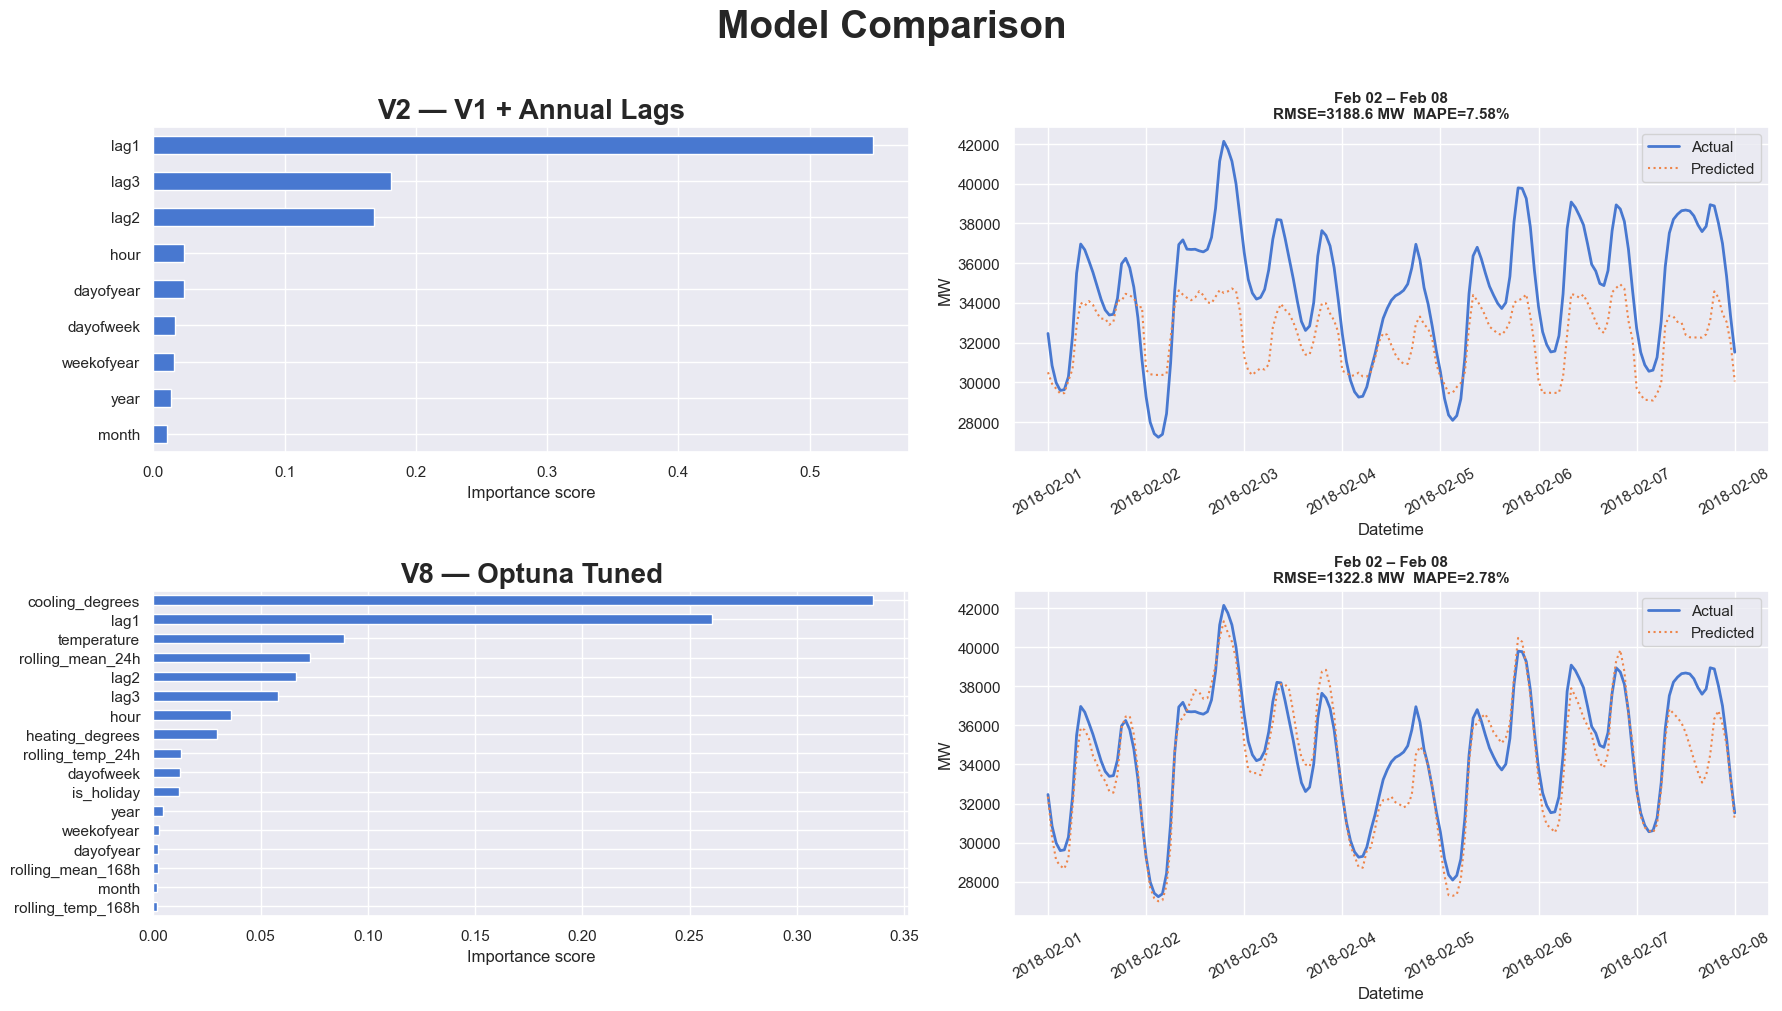

In [ ]:
best_params = {
  # **study.best_params :
  'learning_rate': 0.01615937643864829, 'max_depth': 8, 'subsample': 0.6497348860621205, 'colsample_bytree': 0.8385755832634433, 'min_child_weight': 3, 'reg_alpha': 0.4826264470102635, 'reg_lambda': 2.5147801429932475,

  'n_estimators': 2000,
  'early_stopping_rounds': 50,
  'eval_metric':  'rmse',
  'seed': 42,
}

result_tuned = run_experiment(df, 'V8 — Optuna Tuned', V7_FEATURES, best_params, tscv)
plot_comparison([results[1], result_tuned])  # assuming results[1] is V7

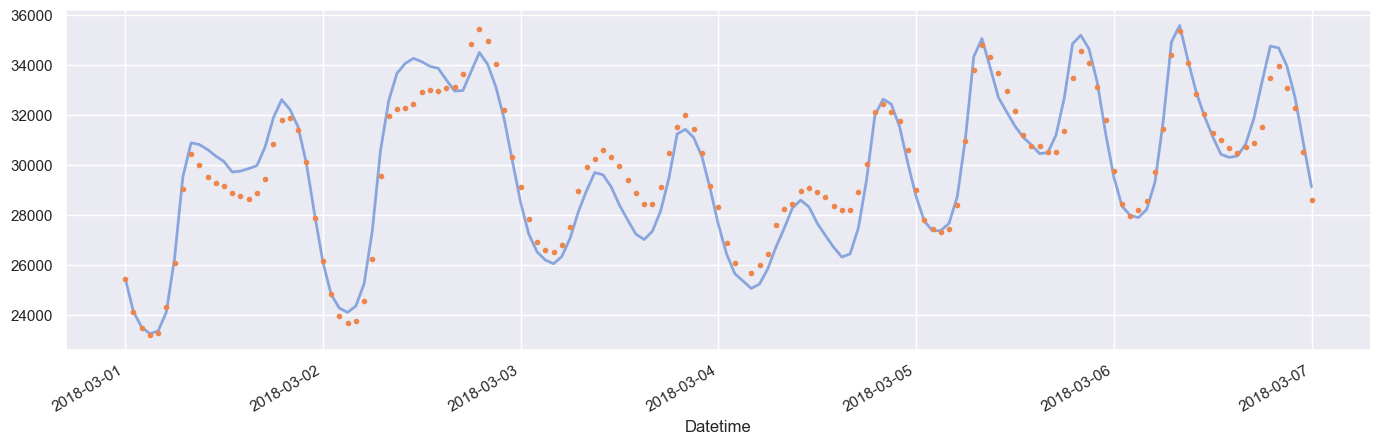

In [20]:
YEAR = 2018
MONTH = 3

predictions_v8 = result_tuned["predictions"]

mask = (predictions_v8.index >= f'{YEAR}-{MONTH}-01') & (predictions_v8.index <= f'{YEAR}-{MONTH}-07')
predictions_v8.loc[mask, "actual"].plot(linewidth=2, alpha=0.6)
predictions_v8.loc[mask, "predicted"].plot(
  style=".",
  linewidth=3
)
plt.show()

### Retrain V7 on all data

In [17]:
# Train on full dataset with best params
final_model = xgb.XGBRegressor(**best_params)
final_model.fit(
  df[V7_FEATURES], df[TARGET],
  eval_set=[(df[V7_FEATURES], df[TARGET])],
  verbose=100
)

# Save
final_model.save_model('../models/v8_xgboost_pjme.json')

print("Model saved.")

[0]	validation_0-rmse:6415.92676
[100]	validation_0-rmse:1829.96158
[200]	validation_0-rmse:1030.14440
[300]	validation_0-rmse:846.24941
[400]	validation_0-rmse:767.42612
[500]	validation_0-rmse:717.12851
[600]	validation_0-rmse:681.85388
[700]	validation_0-rmse:653.63467
[800]	validation_0-rmse:628.32449
[900]	validation_0-rmse:604.45975
[1000]	validation_0-rmse:583.47394
[1100]	validation_0-rmse:564.29809
[1200]	validation_0-rmse:546.28347
[1300]	validation_0-rmse:529.94630
[1400]	validation_0-rmse:514.92557
[1500]	validation_0-rmse:500.62949
[1600]	validation_0-rmse:486.70664
[1700]	validation_0-rmse:473.59588
[1800]	validation_0-rmse:461.54386
[1900]	validation_0-rmse:449.70927
[1999]	validation_0-rmse:438.84295
Model saved.
